In [1]:
%pip install crepe tensorflow librosa matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import crepe
import librosa
import numpy as np
import matplotlib.pyplot as plt

def analyze_pitch_with_crepe(audio_path):
    # 1. 오디오 로드 (CREPE는 16kHz 샘플링 레이트를 권장)
    audio, sr = librosa.load(audio_path, sr=16000)
    
    # 2. CREPE로 Pitch 추정
    # model_capacity: 'tiny', 'small', 'medium', 'large', 'full' (사양에 따라 선택)
    # step_size: 분석 간격 (ms)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True, model_capacity='medium', step_size=10)
    
    # 3. 데이터 필터링 (confidence에 따라 사람 말소리 구분하기 때문에 기준 필요. 0.5로 설정)
    filtered_freq = np.where(confidence > 0.5, frequency, np.nan)

    # 4. 시각화
    plt.figure(figsize=(15, 6))
    
    # 배경으로 파형(Waveform) 표시
    librosa.display.waveshow(audio, sr=sr, alpha=0.3, color='gray')
    
    # Pitch(주파수) 그래프 그리기
    plt.scatter(time, filtered_freq, s=2, c=confidence, cmap='viridis', label='Estimated Pitch (Hz)')
    plt.colorbar(label='CREPE Confidence')
    
    plt.title("Interview Pitch Analysis (CREPE)", fontsize=15)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(0, 500)  # 일반적인 성인 목소리 대역 (80~400Hz)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend()
    
    plt.show()

    # 분석 결과 요약
    avg_pitch = np.nanmean(filtered_freq)
    pitch_std = np.nanstd(filtered_freq)
    print(f"\n[분석 요약]")
    print(f"평균 주파수: {avg_pitch:.2f} Hz")
    print(f"주파수 변동성(표준편차): {pitch_std:.2f} Hz (값이 클수록 억양 변화가 다이나믹함)")

C:\Users\user\AppData\Local\Temp\ipykernel_24012\1155541683.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=16000)
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step


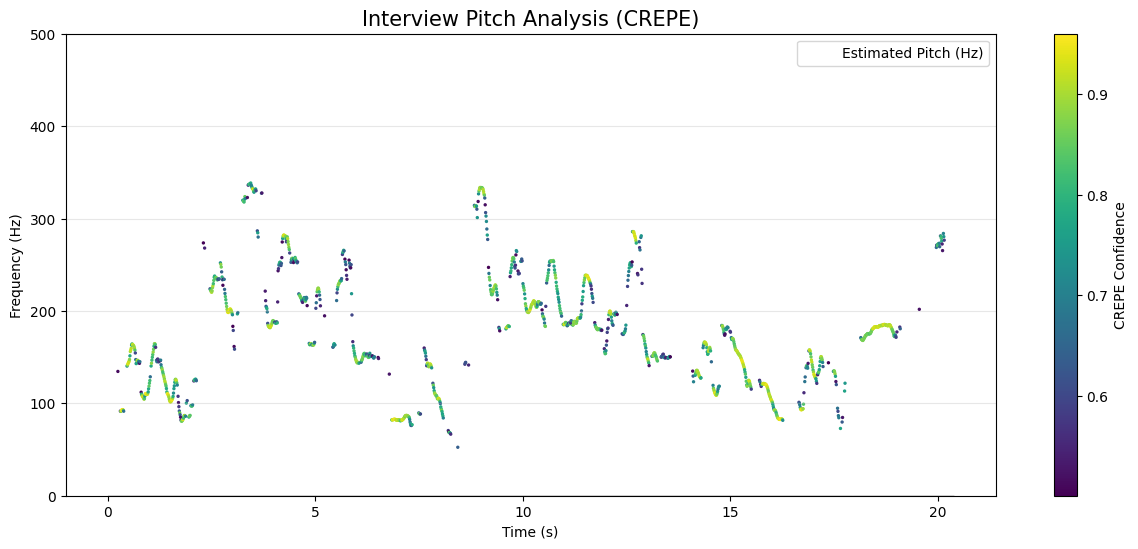


[분석 요약]
평균 주파수: 177.64 Hz
주파수 변동성(표준편차): 61.61 Hz (값이 클수록 억양 변화가 다이나믹함)


In [ ]:
video_path = r"C:\Users\user\Downloads\bad_test.mp4"
analyze_pitch_with_crepe(video_path)

In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip  # 영상 처리를 위해 추가

def analyze_audio_librosa(video_path):
    # 1. 영상에서 오디오 추출
    temp_audio = "temp_for_librosa.wav"
    
    with VideoFileClip(video_path) as clip:
        if clip.audio is None:
            print("❌ 오류: 영상에 오디오 트랙이 없습니다.")
            return
        # librosa, silero는 .wav형태로 입력 필요. (logger=None으로 불필요한 로그 제거)
        clip.audio.write_audiofile(temp_audio, logger=None)

    # 2. 오디오 로드 (Librosa)
    y, sr = librosa.load(temp_audio)
    
    # 3. RMS Energy 추출 (목소리 크기/자신감)
    rms = librosa.feature.rms(y=y)[0]
    times_rms = librosa.frames_to_time(range(len(rms)), sr=sr)

    # 4. Pitch 추출 (고저/톤 안정성)
    f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
    times_f0 = librosa.times_like(f0)

    # 5. 수치적 지표 계산
    clean_f0 = f0[~np.isnan(f0)]
    avg_energy = np.mean(rms)
    energy_std = np.std(rms)
    avg_pitch = np.mean(clean_f0) if len(clean_f0) > 0 else 0
    pitch_std = np.std(clean_f0) if len(clean_f0) > 0 else 0

    # 6. 시각화 (그래프 그리기)
    plt.figure(figsize=(15, 10))

    # (상단) 파형과 에너지
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.3, color='gray')
    plt.plot(times_rms, rms, label='RMS Energy (Volume)', color='blue', linewidth=2)
    plt.title("Voice Intensity & Confidence Analysis", fontsize=15)
    plt.ylabel("Amplitude / Energy")
    plt.legend()

    # (하단) Pitch 변화
    plt.subplot(2, 1, 2)
    plt.plot(times_f0, f0, label='Pitch (Hz)', color='green', marker='o', markersize=2, linestyle='None')
    plt.axhline(y=avg_pitch, color='red', linestyle='--', label=f'Avg Pitch: {avg_pitch:.1f}Hz')
    plt.title("Voice Tone & Stability Analysis", fontsize=15)
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.ylim(0, 500)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 결과 리포트
    print(f"\n===== 면접 음성 정밀 분석 결과 =====")
    print(f"1. 목소리 크기(평균 에너지): {avg_energy:.4f}")
    print(f"2. 발성 일관성(에너지 편차): {energy_std:.4f} (낮을수록 안정적)")
    print(f"3. 평균 음높이(Pitch): {avg_pitch:.2f} Hz")
    print(f"4. 톤 변동성(표준편차): {pitch_std:.2f} Hz")
    print(f"====================================")

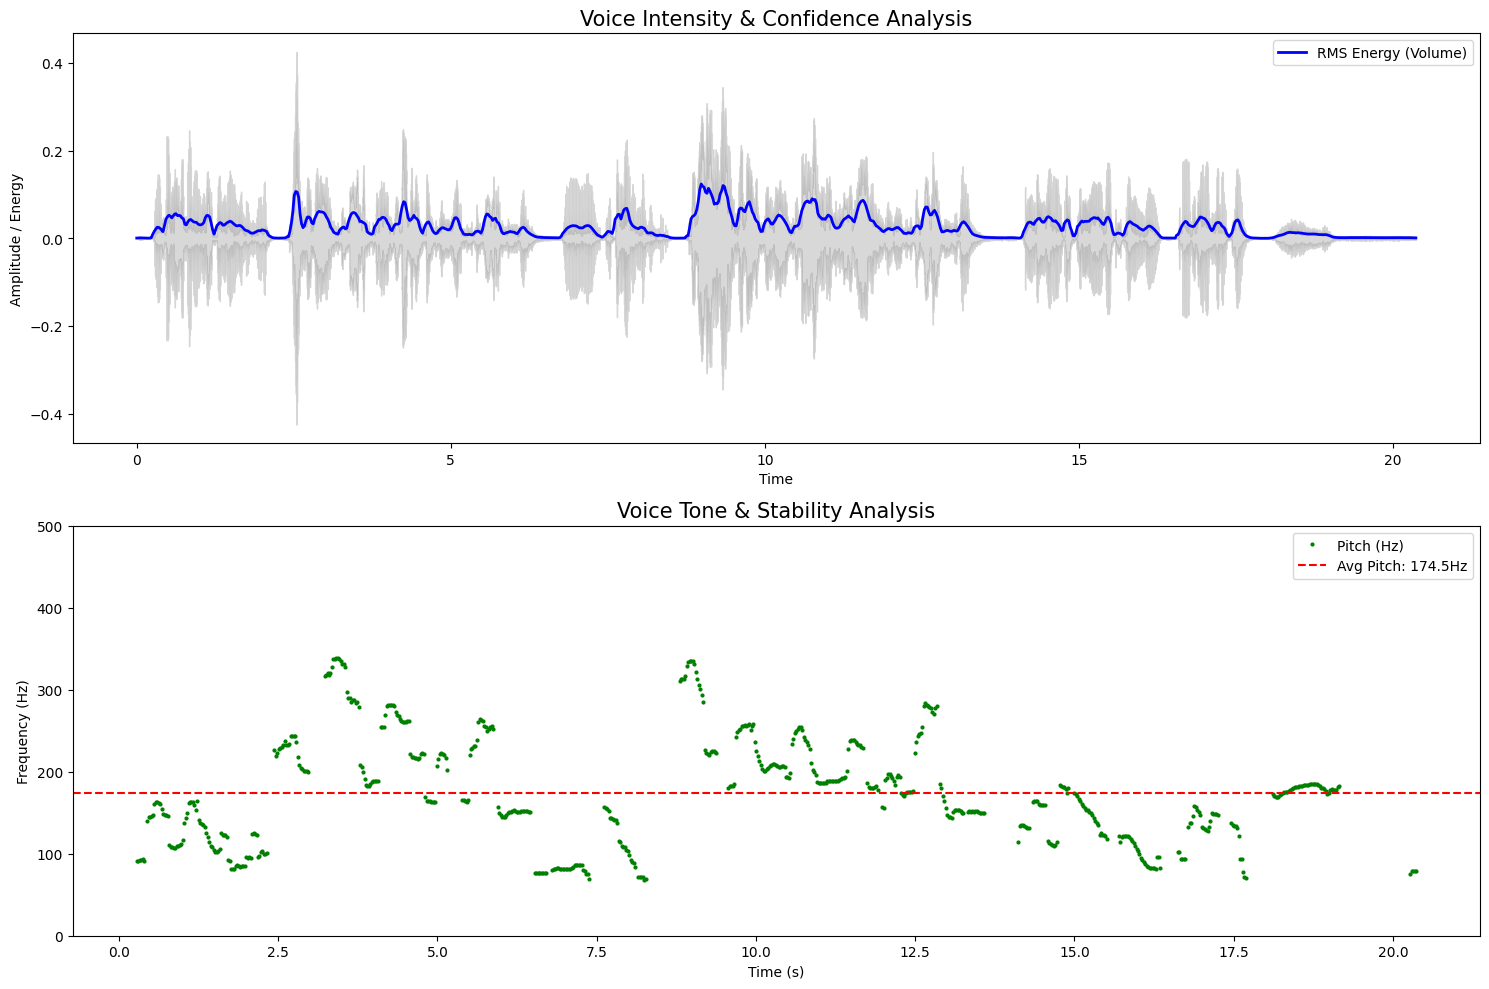


===== 면접 음성 정밀 분석 결과 =====
1. 목소리 크기(평균 에너지): 0.0270
2. 발성 일관성(에너지 편차): 0.0237 (낮을수록 안정적)
3. 평균 음높이(Pitch): 174.48 Hz
4. 톤 변동성(표준편차): 64.50 Hz


In [ ]:
video_path = r"C:\Users\user\Downloads\bad_test.mp4"
analyze_audio_librosa(video_path)